<a href="https://colab.research.google.com/github/marcosgustavom2014-ship-it/EngenhariadePrompt/blob/main/Aula_07_ProgramacaoAssistidaPorAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 07 _ Miniprojeto

Nome: Kadidja Valéria
Disciplina: Engenharia de Prompt e Aplicação em IA

In [ ]:
print("Olá, turma de quarta-feira!")

Olá, turma de quarta-feira!


In [ ]:
#SOMA DE LISTA
numeros = [1,1,1,1,1] # Exemplo de lista
soma = sum(numeros)
print(soma)

5


In [ ]:
import math

#Numero primo
def eh_primo(n):
  if n < 2:
    return False
  if n == 2:
    return True
  if n % 2 == 0: # Otimização: Elimina números pares maiores que 2
    return False
  # Verifica divisores ímpares a partir de 3 até a raiz quadrada de n
  for i in range(3, int(n**0.5) + 1, 2):
    if n % i == 0:
      return False
  return True

In [ ]:
print(f'7 é primo? {eh_primo(7)}') # Esperado: True
print(f'10 é primo? {eh_primo(10)}') # Esperado: False
print(f'2 é primo? {eh_primo(2)}')   # Esperado: True
print(f'1 é primo? {eh_primo(1)}')   # Esperado: False
print(f'11 é primo? {eh_primo(11)}') # Esperado: True
print(f'97 é primo? {eh_primo(97)}') # Esperado: True (exemplo de número maior)

7 é primo? True
10 é primo? False
2 é primo? True
1 é primo? False
11 é primo? True
97 é primo? True


In [ ]:
def inverte_texto(texto):
  # Usando slicing para inverter a string
  return texto[::-1]

# Exemplo de como usar a função e imprimir o resultado
minha_string = "olá mundo"
string_invertida = inverte_texto(minha_string)
print(string_invertida)

odnum álo


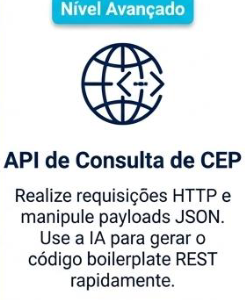

In [ ]:
import requests
import json

def consultar_cep(cep):
    """
    Consulta um CEP utilizando a API ViaCEP.
    Retorna os dados do endereço em formato JSON.
    """
    # A API ViaCEP geralmente não precisa de autenticação para consultas simples.
    # Formato da URL da API ViaCEP:
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Faz a requisição HTTP GET para a API
        response = requests.get(url)
        response.raise_for_status()  # Levanta um HTTPError para respostas de erro (4xx ou 5xx)

        # Tenta decodificar a resposta JSON
        data = response.json()

        # ViaCEP retorna um dicionário com uma chave 'erro' se o CEP for inválido
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP {cep} não encontrado ou inválido.")
            return None
        else:
            return data

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP: {http_err} - Status Code: {response.status_code}")
        return None
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de Conexão: {conn_err}")
        return None
    except requests.exceptions.Timeout as timeout_err:
        print(f"Erro de Timeout: {timeout_err}")
        return None
    except requests.exceptions.RequestException as req_err:
        print(f"Erro inesperado na requisição: {req_err}")
        return None
    except json.JSONDecodeError:
        print("Erro ao decodificar a resposta JSON.")
        print(f"Resposta da API (texto): {response.text}")
        return None

# --- Exemplo de uso ---

# Consulta um CEP válido
cep_valido = "01001000"  # São Paulo, SP
dados_cep = consultar_cep(cep_valido)

if dados_cep:
    print(f"\nDados do CEP {cep_valido}:")
    print(json.dumps(dados_cep, indent=4, ensure_ascii=False)) # Imprime JSON formatado
    print(f"Endereço: {dados_cep.get('logradouro')}, {dados_cep.get('bairro')} - {dados_cep.get('localidade')}/{dados_cep.get('uf')}")

# Consulta um CEP inválido
cep_invalido = "99999999"
dados_cep_invalido = consultar_cep(cep_invalido)

if not dados_cep_invalido:
    print(f"\nComo esperado, nenhum dado retornado para o CEP inválido {cep_invalido}.")


# --- Boilerplate REST Client (mais genérico) ---

class RESTClient:
    def __init__(self, base_url):
        self.base_url = base_url

    def _make_request(self, method, endpoint, params=None, data=None, json_data=None, headers=None):
        url = f"{self.base_url}/{endpoint}"
        try:
            response = requests.request(method, url, params=params, data=data, json=json_data, headers=headers)
            response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
            return response.json() # Assume JSON response
        except requests.exceptions.HTTPError as http_err:
            print(f"HTTP error occurred: {http_err} - {response.status_code} - {response.text}")
        except requests.exceptions.ConnectionError as conn_err:
            print(f"Connection error occurred: {conn_err}")
        except requests.exceptions.Timeout as timeout_err:
            print(f"Timeout error occurred: {timeout_err}")
        except requests.exceptions.RequestException as e:
            print(f"An unexpected error occurred: {e}")
        except json.JSONDecodeError:
            print(f"Failed to decode JSON from response: {response.text}")
        return None

    def get(self, endpoint, params=None, headers=None):
        return self._make_request('GET', endpoint, params=params, headers=headers)

    def post(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('POST', endpoint, data=data, json_data=json_data, headers=headers)

    def put(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('PUT', endpoint, data=data, json_data=json_data, headers=headers)

    def delete(self, endpoint, headers=None):
        return self._make_request('DELETE', endpoint, headers=headers)

# --- Exemplo de uso do cliente REST genérico com ViaCEP ---
print("\n--- Exemplo de uso do cliente REST genérico com ViaCEP ---")
cep_api_base_url = "https://viacep.com.br/ws"
cep_client = RESTClient(cep_api_base_url)

# Endpoint para consulta de CEP é "{cep}/json/"
# Vamos consultar o mesmo CEP válido
cep_para_cliente = "01001000"
endpoint = f"{cep_para_cliente}/json/"
dados_via_cliente = cep_client.get(endpoint)

if dados_via_cliente:
    print(f"\nDados do CEP {cep_para_cliente} (via RESTClient genérico):")
    print(json.dumps(dados_via_cliente, indent=4, ensure_ascii=False))
else:
    print(f"Falha ao obter dados para o CEP {cep_para_cliente} via RESTClient genérico.")





Dados do CEP 01001000:
{
    "cep": "01001-000",
    "logradouro": "Praça da Sé",
    "complemento": "lado ímpar",
    "unidade": "",
    "bairro": "Sé",
    "localidade": "São Paulo",
    "uf": "SP",
    "estado": "São Paulo",
    "regiao": "Sudeste",
    "ibge": "3550308",
    "gia": "1004",
    "ddd": "11",
    "siafi": "7107"
}
Endereço: Praça da Sé, Sé - São Paulo/SP
Erro: CEP 99999999 não encontrado ou inválido.

Como esperado, nenhum dado retornado para o CEP inválido 99999999.

--- Exemplo de uso do cliente REST genérico com ViaCEP ---

Dados do CEP 01001000 (via RESTClient genérico):
{
    "cep": "01001-000",
    "logradouro": "Praça da Sé",
    "complemento": "lado ímpar",
    "unidade": "",
    "bairro": "Sé",
    "localidade": "São Paulo",
    "uf": "SP",
    "estado": "São Paulo",
    "regiao": "Sudeste",
    "ibge": "3550308",
    "gia": "1004",
    "ddd": "11",
    "siafi": "7107"
}


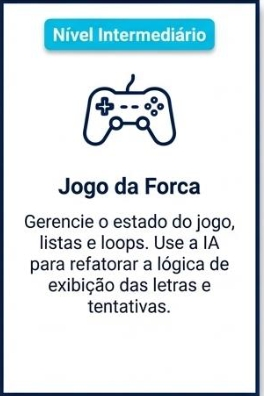

O segredo da refatoração aqui é o uso de List Comprehension (em Python) ou métodos de array como .map() (em JS). Isso substitui blocos de if/else dentro de loops manuais.

In [ ]:

# Estado Inicial
palavra_secreta = "PROGRAMACAO"
letras_adivinhadas = ["P", "R", "A"]
tentativas_maximas = 6

def exibir_jogo(palavra, palpites, tentativas):
    # Refatoração da exibição da palavra
    # Se a letra está nos palpites, mostra a letra; senão, mostra "_"
    visualizacao = [letra if letra in palpites else "_" for letra in palavra]

    print("\n" + "="*20)
    print(f"Palavra: {' '.join(visualizacao)}")
    print(f"Tentativas restantes: {tentativas}")
    print(f"Letras já tentadas: {', '.join(palpites)}")
    print("="*20)

# Chamada da função
exibir_jogo(palavra_secreta, letras_adivinhadas, tentativas_maximas)


Palavra: P R _ _ R A _ A _ A _
Tentativas restantes: 6
Letras já tentadas: P, R, A


Para gerenciar as tentativas, usamos um loop while que consulta o estado a cada rodada

In [ ]:
while tentativas_maximas > 0:
    exibir_jogo(palavra_secreta, letras_adivinhadas, tentativas_maximas)

    palpite = input("Digite uma letra: ").upper()

    if palpite in letras_adivinhadas:
        print("Você já tentou essa letra!")
        continue

    letras_adivinhadas.append(palpite)

    if palpite not in palavra_secreta:
        tentativas_maximas -= 1
        print(f"Erro! Você perdeu uma vida.")

    # Verificação de Vitória
    if all(letra in letras_adivinhadas for letra in palavra_secreta):
        print(f"Parabéns! A palavra era: {palavra_secreta}")
        break
else:
    print(f"Fim de jogo! A palavra era: {palavra_secreta}")

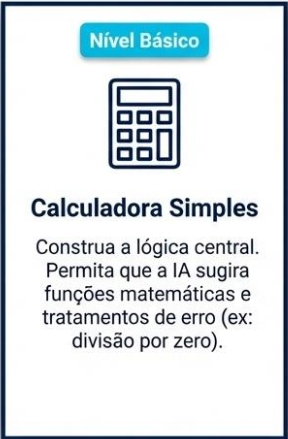

Em vez de colocar tudo dentro de um emaranhado de if/else, podemos isolar as funções:

In [ ]:
def calculadora():
    print("--- Calculadora Simples ---")

    while True:
        print("\nEscolha a operação:")
        print("1. Soma (+)")
        print("2. Subtração (-)")
        print("3. Multiplicação (*)")
        print("4. Divisão (/)")
        print("5. Sair")

        opcao = input("Digite sua opção (1/2/3/4/5): ")

        if opcao == '5':
            print("Encerrando... Até logo!")
            break

        if opcao in ('1', '2', '3', '4'):
            try:
                num1 = float(input("Primeiro número: "))
                num2 = float(input("Segundo número: "))
            except ValueError:
                print("Entrada inválida! Digite apenas números.")
                continue

            if opcao == '1':
                print(f"Resultado: {somar(num1, num2)}")
            elif opcao == '2':
                print(f"Resultado: {subtrair(num1, num2)}")
            elif opcao == '3':
                print(f"Resultado: {multiplicar(num1, num2)}")
            elif opcao == '4':
                print(f"Resultado: {dividir(num1, num2)}")
        else:
            print("Opção inválida!")

# Inicia o programa
calculadora()

Funções Matemáticas Avançadas

Além do básico, você pode usar a biblioteca nativa math do Python para expandir o poder de fogo do seu código:

Potenciação ($a^b$): Útil para crescimentos exponenciais.Raiz Quadrada ($\sqrt{x}$): Essencial para cálculos geométricos.Resto da Divisão (%): Ótimo para verificar se um número é par ou ímpar.

In [ ]:
import math

def potencia(a, b):
    return a ** b

def raiz_quadrada(a):
    if a < 0:
        return "Erro: Não existe raiz de número negativo nos Reais."
    return math.sqrt(a)

def resto_divisao(a, b):
    return a % b

Refatorando o Tratamento de Erros

O segredo de um código robusto é prever onde ele pode falhar. No caso da divisão por zero, temos duas abordagens principais:

A) A Abordagem Preventiva (Lógica if)

Você verifica a condição antes do erro acontecer. É a mais comum para calculadoras simples.

In [ ]:
def dividir(a, b):
    if b == 0:
        return "Erro: O divisor não pode ser zero."
    return a / b

B) A Abordagem "Pythonica" (try/except)

Em Python, muitas vezes é melhor "pedir desculpas do que permissão". Você tenta executar a operação e captura o erro específico se ele ocorrer.

In [ ]:
def divisao_robusta(a, b):
    try:
        resultado = a / b
    except ZeroDivisionError:
        return "Erro: Divisão por zero detectada pelo sistema."
    except TypeError:
        return "Erro: Tipo de dado inválido."
    else:
        return resultado

Exemplo de Menu Refatorado

Integrando o tratamento de erros no fluxo principal:

In [ ]:
while True:
    try:
        n1 = float(input("Número 1: "))
        op = input("Operação (+, -, *, /, sqrt): ")

        if op == 'sqrt':
            print(f"Resultado: {raiz_quadrada(n1)}")
            continue

        n2 = float(input("Número 2: "))

        if op == '/':
            print(f"Resultado: {dividir(n1, n2)}")
        # ... outras operações

    except ValueError:
        print("Erro: Por favor, digite apenas números válidos.")

1. O Jogo da Forca (O "Organizador de Gavetas")
O pensamento aqui é: "Como eu mostro o progresso sem revelar o segredo?"

O Problema: Eu tenho uma palavra (ex: "BANANA") e o cara só chutou "A". Se eu imprimir a lista de chutes, fica feio. Se eu imprimir a palavra, o jogo acaba.

O Pelo do Gato: Eu crio um filtro. Passo por cada letra da palavra secreta e pergunto: "Ei, essa letra já tá na sacola de chutes do jogador?"

Se tá na sacola, eu mostro.

Se não tá, eu escondo com um risquinho.

A Sacada Humana: Em vez de ficar criando variáveis malucas tipo acerto1, acerto2, eu guardo tudo numa lista única e deixo um loop fazer o trabalho sujo de conferir a palavra toda vez que a tela atualiza. É mais limpo e não dá nó na cabeça.

2. A Calculadora (O "Segurança de Balada")
O pensamento aqui é: "Como eu impeço o usuário de explodir o meu programa?"

O Problema: O usuário é imprevisível. Ele vai tentar dividir por zero ou digitar "vinte" em vez de "20". Se o programa tentar calcular isso puro, ele "morre" (dá crash).

A Estratégia de Defesa:

Isolamento: Eu coloco cada conta numa caixinha (função). Se a conta da divisão der pau, o problema tá só ali.

O "E se?": Antes de fazer a conta, eu dou uma olhada: "O segundo número é zero?". Se for, eu nem tento; já grito logo o erro.

A Rede de Proteção: Uso o try/except como se fosse um airbag. Eu falo pro computador: "Tenta fazer isso aí, se você se quebrar no caminho, não trava não... só me avisa que eu aviso o usuário".

A Sacada Humana: Tratar erro não é "corrigir o código", é prever o comportamento humano. É fazer o programa ser resiliente a cliques errados.

Resumo do Resumo
Na Forca, a gente focou em exibir dados de um jeito inteligente usando listas.

Na Calculadora, a gente focou em blindar o fluxo de dados contra erros bobos.